In [1]:
# Package imports

import torch
import vizdoom
import vizdoom
from vizdoom import gymnasium_wrapper
import gymnasium
import yaml

In [2]:
# Sys level imports

import sys
sys.path.append('.')
from scripts.env_setup import collect_rollouts, batch_frames

Initial setup and yaml reading

In [3]:
with open("config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)

# Vizdoom env variables
VIZDOOM_CONFIG = CONFIG["vizdoom-env"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VAE_TRAINING_PARAMS = CONFIG["vae"]["training-params"]
VAE_MODEL_LOC = CONFIG["vae"]["model-path"]

MDNRNN_TRAINING_PARAMS = CONFIG["mdnrnn"]["training-params"]
MDNRNN_MODEL_LOC = CONFIG["mdnrnn"]["model-path"]

In [4]:
env = gymnasium.make(VIZDOOM_CONFIG, screen_resolution=vizdoom.ScreenResolution.RES_200X125)
frames, actions, game_states, rewards, done_list = collect_rollouts(env=env, episodes=1)

Rolling out Episode: 1/1: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s]


[ 79. 100.]
2


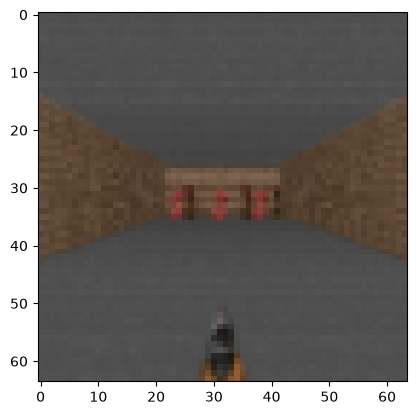

In [10]:
import matplotlib.pyplot as plt

plt.imshow(frames[0].permute(1, 2, 0))
print(game_states[0])
print(actions[0])

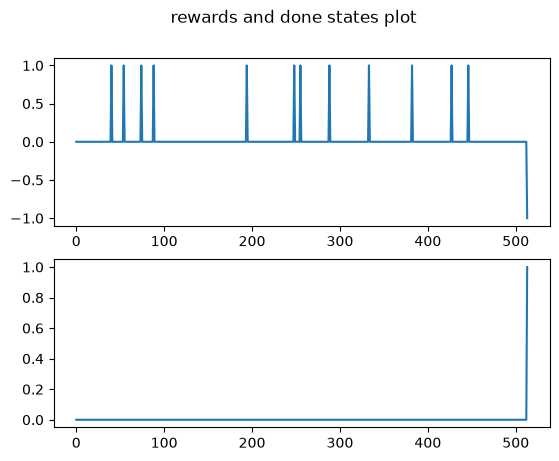

In [14]:
fig, ax = plt.subplots(2)
fig.suptitle('rewards and done states plot')
ax[0].plot(rewards)
ax[1].plot(done_list)